In [ ]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import PercentFormatter
sns.set(style="whitegrid")

In [ ]:
# Lista zmiennych ryzyka
tickers = {
    "XLF": "XLF",
    "GLD": "GLD",
}

# Pobieranie danych i automatyczna korekta o dywidendy i splity
raw_data = yf.download(
    tickers=list(tickers.values()),
    start="2020-06-01",
    end="2025-06-01",
    group_by="ticker",
    auto_adjust=False
)

# Budowa DataFrame z cenami zamknięcia
adj_close = pd.DataFrame({
    label: raw_data[ticker]["Close"]
    for label, ticker in tickers.items()
})

# Czyszczenie i obliczenie dziennych stóp zwrotu
adj_close = adj_close.dropna()
returns = adj_close.pct_change().dropna()

[*********************100%***********************]  2 of 2 completed


In [ ]:
# Średnie dzienne stopy zwrotu
mean_returns = returns.mean()

# Odchylenia standardowe (ryzyko)
std_devs = returns.std()

# Macierz korelacji
correlation_matrix = returns.corr()

print("Średnie zwroty (dzienne):\n", mean_returns)
print("\nOdchylenia standardowe (dzienne):\n", std_devs)
print("\nKorelacje:\n", correlation_matrix)

# --- Konwersja na skalę roczną (252 dni handlowych) ---


# 2) uśrednij je i przelicz na roczne CAGR:
annual_mean_returns = mean_returns * 252

# 3) volatility roczne tak jak wcześniej:
annual_std_devs = std_devs * np.sqrt(252)



print("\nŚrednie zwroty (roczne):\n", annual_mean_returns)
print("\nOdchylenia standardowe (roczne):\n", annual_std_devs)




Średnie zwroty (dzienne):
 XLF    0.000696
GLD    0.000539
dtype: float64

Odchylenia standardowe (dzienne):
 XLF    0.013057
GLD    0.009676
dtype: float64

Korelacje:
           XLF       GLD
XLF  1.000000  0.009285
GLD  0.009285  1.000000

Średnie zwroty (roczne):
 XLF    0.175285
GLD    0.135812
dtype: float64

Odchylenia standardowe (roczne):
 XLF    0.207266
GLD    0.153595
dtype: float64


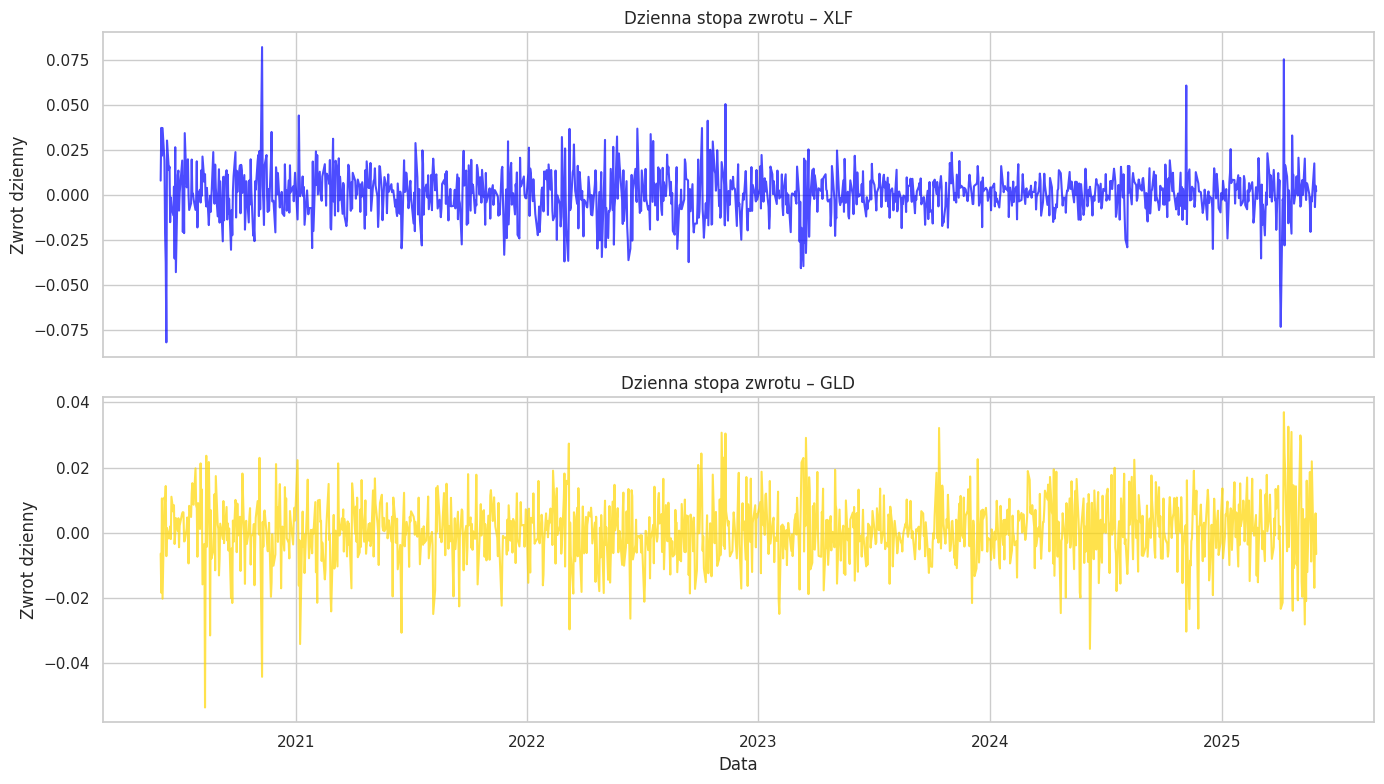

In [ ]:
import matplotlib.pyplot as plt

# Tworzymy dwa wykresy jeden pod drugim
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# Wykres dla XLF
ax1.plot(returns.index, returns["XLF"], color="blue", alpha=0.7)
ax1.set_title("Dzienna stopa zwrotu – XLF")
ax1.set_ylabel("Zwrot dzienny")
ax1.grid(True)

# Wykres dla GLD
ax2.plot(returns.index, returns["GLD"], color="gold", alpha=0.7)
ax2.set_title("Dzienna stopa zwrotu – GLD")
ax2.set_ylabel("Zwrot dzienny")
ax2.set_xlabel("Data")
ax2.grid(True)

plt.tight_layout()
plt.show()


In [ ]:
# CELL 3 – oczekiwana stopa zwrotu i ryzyko portfela

weights = np.array([0.6, 0.4])  # 60% XLF, 40% GLD

# Oczekiwana stopa zwrotu portfela (dzienne)
expected_return = np.dot(weights, mean_returns)

# Wariancja i odchylenie standardowe portfela (dzienne)
cov_matrix = returns.cov()
portfolio_variance = np.dot(weights.T, np.dot(cov_matrix, weights))
portfolio_std_dev = np.sqrt(portfolio_variance)

# Konwersja na skalę roczną (252 dni handlowych)
expected_return_annual = expected_return * 252
portfolio_std_dev_annual = portfolio_std_dev * np.sqrt(252)

# Wyniki
print("Stopa zwrotu portfela:")
print(f"- Dzienne: {expected_return:.6f}  (≈ {expected_return*100:.4f}%)")
print(f"- Roczne:  {expected_return_annual:.6f}  (≈ {expected_return_annual*100:.2f}%)\n")

print("Ryzyko portfela (odchylenie standardowe):")
print(f"- Dzienne σ: {portfolio_std_dev:.6f}  (≈ {portfolio_std_dev*100:.4f}%)")
print(f"- Roczne σ:  {portfolio_std_dev_annual:.6f}  (≈ {portfolio_std_dev_annual*100:.2f}%)")


Stopa zwrotu portfela:
- Dzienne: 0.000633  (≈ 0.0633%)
- Roczne:  0.159496  (≈ 15.95%)

Ryzyko portfela (odchylenie standardowe):
- Dzienne σ: 0.008770  (≈ 0.8770%)
- Roczne σ:  0.139219  (≈ 13.92%)


In [ ]:
weights_list = []
returns_list = []
risks_list = []
annual_returns_list = []
annual_risks_list = []

TRADING_DAYS = 252

for w in np.linspace(0, 1, 100):  # 100 punktów od 0 do 1
    weights = np.array([w, 1 - w])  # np. [XLF, GLD]

    # Oczekiwany dzienny zwrot
    expected_return_daily = np.dot(weights, returns.mean())

    # Dzienna wariancja i odchylenie standardowe (σ)
    cov_matrix = returns.cov()
    variance_daily = np.dot(weights.T, np.dot(cov_matrix, weights))
    std_dev_daily = np.sqrt(variance_daily)

    # Annualizacja
    expected_return_annual = expected_return_daily * TRADING_DAYS
    std_dev_annual = std_dev_daily * np.sqrt(TRADING_DAYS)

    # Zapisywanie wyników
    weights_list.append(weights)
    returns_list.append(expected_return_daily)
    risks_list.append(std_dev_daily)
    annual_returns_list.append(expected_return_annual)
    annual_risks_list.append(std_dev_annual)

# Przykładowe wypisanie pierwszych 5 portfeli
for i in range(5):
    w_xlf, w_gld = weights_list[i]
    print(f"Portfel {i+1}: XLF={w_xlf:.2f}, GLD={w_gld:.2f}")
    print(f"  • Dzienne: zwrot={returns_list[i]:.6f}, σ={risks_list[i]:.6f}")
    print(f"  • Roczne: zwrot={annual_returns_list[i]:.6f}, σ={annual_risks_list[i]:.6f}\n")


Portfel 1: XLF=0.00, GLD=1.00
  • Dzienne: zwrot=0.000539, σ=0.009676
  • Roczne: zwrot=0.135812, σ=0.153595

Portfel 2: XLF=0.01, GLD=0.99
  • Dzienne: zwrot=0.000541, σ=0.009580
  • Roczne: zwrot=0.136211, σ=0.152077

Portfel 3: XLF=0.02, GLD=0.98
  • Dzienne: zwrot=0.000542, σ=0.009486
  • Roczne: zwrot=0.136609, σ=0.150589

Portfel 4: XLF=0.03, GLD=0.97
  • Dzienne: zwrot=0.000544, σ=0.009394
  • Roczne: zwrot=0.137008, σ=0.149131

Portfel 5: XLF=0.04, GLD=0.96
  • Dzienne: zwrot=0.000545, σ=0.009304
  • Roczne: zwrot=0.137407, σ=0.147704



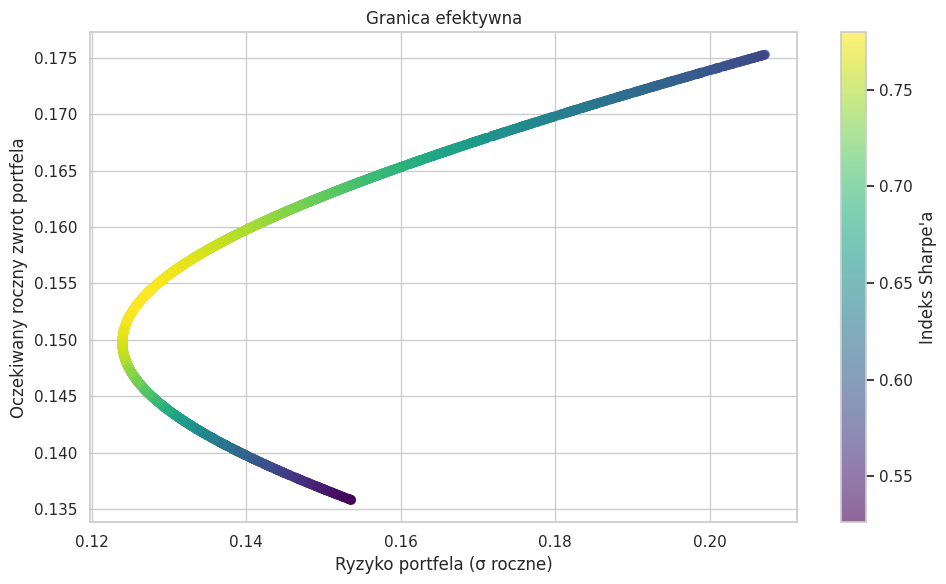

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Parametry
n_portfolios = 5000
mean_returns = returns.mean() * 252
cov_matrix = returns.cov() * 252
risk_free_rate = 0.055  # 5.5% rocznie

# Miejsce na dane
returns_array = []
volatility_array = []
sharpe_array = []

# Generowanie portfeli
for _ in range(n_portfolios):
    weights = np.random.random(len(tickers))
    weights /= np.sum(weights)

    port_return = np.dot(weights, mean_returns)
    port_vol = np.sqrt(np.dot(weights.T, np.dot(cov_matrix, weights)))
    sharpe = (port_return - risk_free_rate) / port_vol

    returns_array.append(port_return)
    volatility_array.append(port_vol)
    sharpe_array.append(sharpe)

# Konwersja do tablic
returns_array = np.array(returns_array)
volatility_array = np.array(volatility_array)
sharpe_array = np.array(sharpe_array)

# Wykres Efficient Frontier z kolorowaniem Sharpe, bez gwiazdki
plt.figure(figsize=(10, 6))
sc = plt.scatter(volatility_array, returns_array, c=sharpe_array, cmap='viridis', alpha=0.6)
plt.colorbar(sc, label='Indeks Sharpe\'a')

plt.title('Granica efektywna')
plt.xlabel('Ryzyko portfela (σ roczne)')
plt.ylabel('Oczekiwany roczny zwrot portfela')
plt.grid(True)
plt.tight_layout()
plt.show()


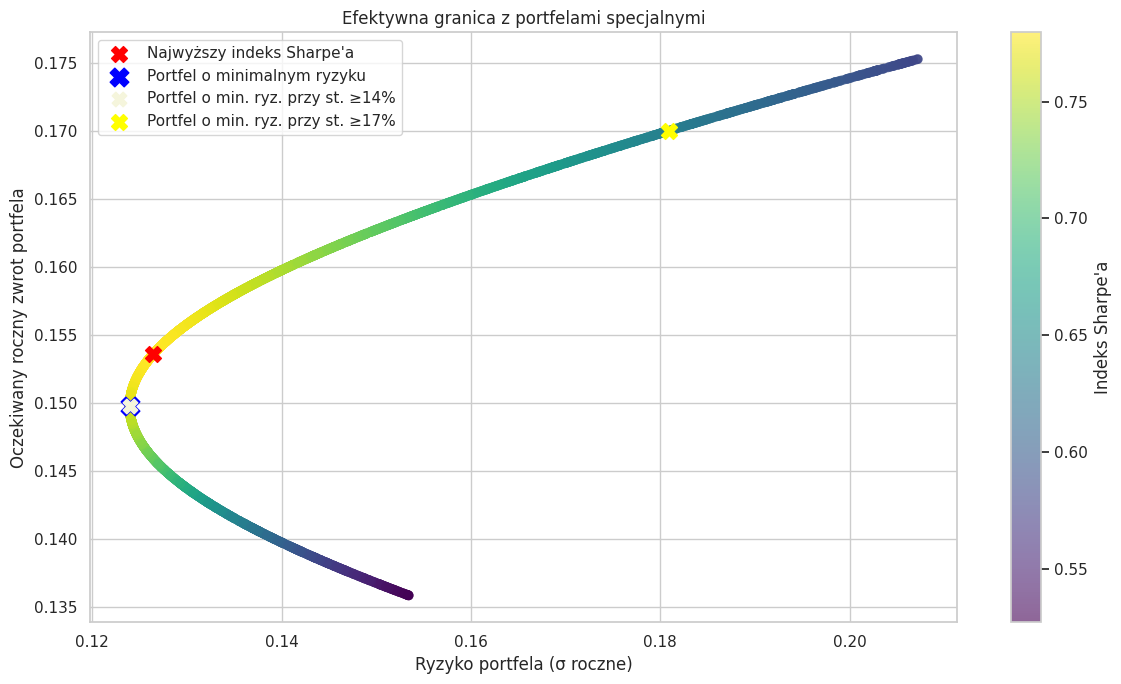

Portfel o najwyższym Sharpe:
  Zwrot: 15.36%
  Ryzyko: 12.64%
  Wagi: {'XLF': np.float64(0.4501), 'GLD': np.float64(0.5499)}

Portfel o minimalnym ryzyku:
  Zwrot: 14.98%
  Ryzyko: 12.40%
  Wagi: {'XLF': np.float64(0.3532), 'GLD': np.float64(0.6468)}

Portfel o minimalnym ryzyku przy zwrocie ≥ 14%:
  Zwrot: 14.98%
  Ryzyko: 12.40%
  Wagi: {'XLF': np.float64(0.3532), 'GLD': np.float64(0.6468)}

Portfel o minimalnym ryzyku przy zwrocie ≥ 17%:
  Zwrot: 17.00%
  Ryzyko: 18.09%
  Wagi: {'XLF': np.float64(0.8664), 'GLD': np.float64(0.1336)}



In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Parametry
n_portfolios = 5000
mean_returns = returns.mean() * 252
cov_matrix = returns.cov() * 252
risk_free_rate = 0.055  # 5.5% rocznie

returns_array = []
volatility_array = []
sharpe_array = []
weights_array = []

# Generowanie portfeli
for _ in range(n_portfolios):
    weights = np.random.random(len(tickers))
    weights /= np.sum(weights)

    port_return = np.dot(weights, mean_returns)
    port_vol = np.sqrt(np.dot(weights.T, np.dot(cov_matrix, weights)))
    sharpe = (port_return - risk_free_rate) / port_vol

    weights_array.append(weights)
    returns_array.append(port_return)
    volatility_array.append(port_vol)
    sharpe_array.append(sharpe)

# Tablice NumPy
returns_array = np.array(returns_array)
volatility_array = np.array(volatility_array)
sharpe_array = np.array(sharpe_array)
weights_array = np.array(weights_array)

# Indeksy portfeli specjalnych
max_sharpe_idx = np.argmax(sharpe_array)
min_vol_idx = np.argmin(volatility_array)

# Portfele o minimalnym ryzyku przy ustalonych zwrotach
target_returns = [0.14, 0.17]
target_idxs = []

for target in target_returns:
    mask = returns_array >= target
    if np.any(mask):
        idx_local = np.argmin(volatility_array[mask])
        actual_idx = np.where(mask)[0][idx_local]
        target_idxs.append(actual_idx)
    else:
        target_idxs.append(None)

# Rysunek
plt.figure(figsize=(12, 7))
sc = plt.scatter(volatility_array, returns_array, c=sharpe_array, cmap='viridis', alpha=0.6)
plt.colorbar(sc, label="Indeks Sharpe'a")

# Zaznacz portfele specjalne
plt.scatter(volatility_array[max_sharpe_idx], returns_array[max_sharpe_idx], color='red', s=130, marker='X', label='Najwyższy indeks Sharpe\'a')
plt.scatter(volatility_array[min_vol_idx], returns_array[min_vol_idx], color='blue', s=180, marker='X', label='Portfel o minimalnym ryzyku')

if target_idxs[0] is not None:
    plt.scatter(volatility_array[target_idxs[0]], returns_array[target_idxs[0]], color='beige', s=110, marker='X', label='Portfel o min. ryz. przy st. ≥14%')
if target_idxs[1] is not None:
    plt.scatter(volatility_array[target_idxs[1]], returns_array[target_idxs[1]], color='yellow', s=130, marker='X', label='Portfel o min. ryz. przy st. ≥17%')

plt.xlabel("Ryzyko portfela (σ roczne)")
plt.ylabel("Oczekiwany roczny zwrot portfela")
plt.title("Efektywna granica z portfelami specjalnymi")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Wyświetlanie szczegółów w konsoli:
def print_portfolio_info(idx, name):
    vol = volatility_array[idx]
    ret = returns_array[idx]
    weights = weights_array[idx]
    print(f"{name}:")
    print(f"  Zwrot: {ret:.2%}")
    print(f"  Ryzyko: {vol:.2%}")
    print(f"  Wagi: {dict(zip(tickers.keys(), np.round(weights, 4)))}")
    print()

print_portfolio_info(max_sharpe_idx, "Portfel o najwyższym Sharpe")
print_portfolio_info(min_vol_idx, "Portfel o minimalnym ryzyku")

if target_idxs[0] is not None:
    print_portfolio_info(target_idxs[0], "Portfel o minimalnym ryzyku przy zwrocie ≥ 14%")
if target_idxs[1] is not None:
    print_portfolio_info(target_idxs[1], "Portfel o minimalnym ryzyku przy zwrocie ≥ 17%")


Bieżąca roczna stopa wolna od ryzyka: 0.0446 (4.46%)

Portfel o maksymalnym Sharpe ratio:
  Zwrot roczny: 0.1532
  Ryzyko roczne: 0.1260
  Sharpe ratio: 0.8622
  Wagi portfela rynkowego:
    XLF: 0.4409
    GLD: 0.5591

Portfel mieszany przy oczekiwanym zwrocie 14%:
  Waga portfela rynkowego: 0.8783
  Waga obligacji (stopa wolna od ryzyka): 0.1217
  Ryzyko roczne: 0.1107

Portfel 50/50 (50% portfel rynkowy, 50% obligacja):
  Zwrot roczny: 0.0989 (9.89%)
  Ryzyko roczne: 0.0630 (6.30%)
  Waga portfela rynkowego: 0.50
  Waga obligacji (RF): 0.50


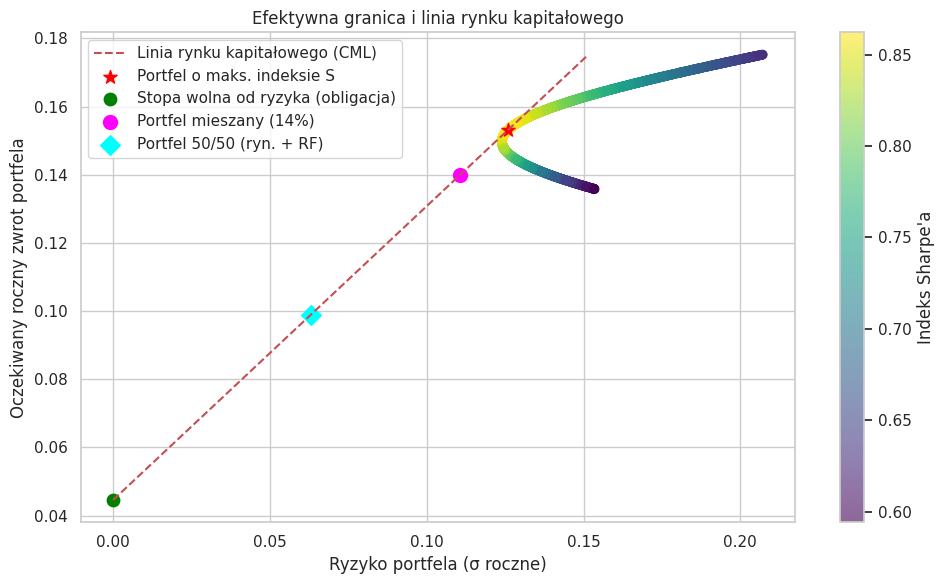

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas_datareader.data as web
from datetime import datetime

TRADING_DAYS = 252

# Zakładamy, że masz DataFrame returns z dziennymi stopami zwrotu
# i listę tickerów, np. tickers = ['XLF', 'GLD']

# Oblicz roczne średnie zwroty i macierz kowariancji
mean_returns = returns.mean() * TRADING_DAYS
cov_matrix = returns.cov() * TRADING_DAYS

# Pobierz bieżącą roczną stopę wolną od ryzyka (rentowność 10-letnich obligacji) z FRED
today = datetime.today().strftime('%Y-%m-%d')
rf_df = web.DataReader('DGS10', 'fred', start='2025-01-01', end=today).dropna()
rf_annual = rf_df.iloc[-1, 0] / 100
print(f"Bieżąca roczna stopa wolna od ryzyka: {rf_annual:.4f} ({rf_annual*100:.2f}%)")

# Generuj losowe portfele i policz ich parametry
n_portfolios = 5000
weights_array = []
returns_array = []
volatility_array = []
sharpe_array = []

for _ in range(n_portfolios):
    weights = np.random.random(len(tickers))
    weights /= np.sum(weights)

    port_return = np.dot(weights, mean_returns)
    port_vol = np.sqrt(np.dot(weights.T, np.dot(cov_matrix, weights)))
    sharpe = (port_return - rf_annual) / port_vol

    weights_array.append(weights)
    returns_array.append(port_return)
    volatility_array.append(port_vol)
    sharpe_array.append(sharpe)

returns_array = np.array(returns_array)
volatility_array = np.array(volatility_array)
sharpe_array = np.array(sharpe_array)
weights_array = np.array(weights_array)

# Znajdź portfel maksymalizujący Sharpe ratio (portfel rynkowy)
max_sharpe_idx = np.argmax(sharpe_array)
best_return = returns_array[max_sharpe_idx]
best_vol = volatility_array[max_sharpe_idx]
best_weights = weights_array[max_sharpe_idx]
best_sharpe = sharpe_array[max_sharpe_idx]

print("\nPortfel o maksymalnym Sharpe ratio:")
print(f"  Zwrot roczny: {best_return:.4f}")
print(f"  Ryzyko roczne: {best_vol:.4f}")
print(f"  Sharpe ratio: {best_sharpe:.4f}")
print("  Wagi portfela rynkowego:")
for ticker, w in zip(tickers, best_weights):
    print(f"    {ticker}: {w:.4f}")

# Capital Market Line (CML)
lambda_vals = np.linspace(0, 1.2, 100)
cml_risk_annual = lambda_vals * best_vol
cml_return_annual = rf_annual + lambda_vals * (best_return - rf_annual)

# Portfel mieszany przy oczekiwanym zwrocie 14%
target_return = 0.14
w_market = (target_return - rf_annual) / (best_return - rf_annual)
w_rf = 1 - w_market
mixed_risk = w_market * best_vol

print(f"\nPortfel mieszany przy oczekiwanym zwrocie 14%:")
print(f"  Waga portfela rynkowego: {w_market:.4f}")
print(f"  Waga obligacji (stopa wolna od ryzyka): {w_rf:.4f}")
print(f"  Ryzyko roczne: {mixed_risk:.4f}")

# Portfel 50/50: 50% portfel rynkowy, 50% obligacja
w_market_50 = 0.5
w_rf_50 = 0.5
mixed50_return = w_market_50 * best_return + w_rf_50 * rf_annual
mixed50_risk = w_market_50 * best_vol  # obligacja ma zerowe ryzyko

print("\nPortfel 50/50 (50% portfel rynkowy, 50% obligacja):")
print(f"  Zwrot roczny: {mixed50_return:.4f} ({mixed50_return*100:.2f}%)")
print(f"  Ryzyko roczne: {mixed50_risk:.4f} ({mixed50_risk*100:.2f}%)")
print(f"  Waga portfela rynkowego: {w_market_50:.2f}")
print(f"  Waga obligacji (RF): {w_rf_50:.2f}")

# Rysowanie wykresu
plt.figure(figsize=(10, 6))
sc = plt.scatter(volatility_array, returns_array, c=sharpe_array, cmap='viridis', alpha=0.6)
plt.colorbar(sc, label='Indeks Sharpe\'a')
plt.plot(cml_risk_annual, cml_return_annual, 'r--', label='Linia rynku kapitałowego (CML)')
plt.scatter(best_vol, best_return, color='red', s=100, marker='*', label='Portfel o maks. indeksie S')
plt.scatter(0, rf_annual, color='green', s=80, label='Stopa wolna od ryzyka (obligacja)')
plt.scatter(mixed_risk, target_return, color='magenta', s=100, marker='o', label='Portfel mieszany (14%)')
plt.scatter(mixed50_risk, mixed50_return, color='cyan', s=100, marker='D', label='Portfel 50/50 (ryn. + RF)')

plt.xlabel('Ryzyko portfela (σ roczne)')
plt.ylabel('Oczekiwany roczny zwrot portfela')
plt.title('Efektywna granica i linia rynku kapitałowego')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [ ]:
import scipy.stats as stats

def var_cov_var(port_vol, confidence_level):
    """
    Oblicza VaR metodą wariancji-kowariancji dla danego ryzyka portfela (σ roczne)
    confidence_level - np. 0.95 lub 0.99
    """
    z = stats.norm.ppf(1 - confidence_level)
    return -z * port_vol  # VaR jako dodatnia strata

# Założenia: zmienne z poprzedniego kodu są dostępne:
# best_return, best_vol, best_weights, rf_annual, mixed_risk, target_return, w_market, w_rf
# oraz tablice volatility_array, returns_array, weights_array, tickers, target_idxs, min_vol_idx, max_sharpe_idx

# Obliczenia dla portfela 50/50: 50% portfel rynkowy, 50% obligacja
w_market_50 = 0.5
w_rf_50 = 0.5
port50_return = w_market_50 * best_return + w_rf_50 * rf_annual
port50_vol = w_market_50 * best_vol
# Wagi poszczególnych aktywów w portfelu 50/50:
weights_50_50_assets = w_market_50 * best_weights  # wagi na XLF, GLD
weights_50_50_rf = w_rf_50  # waga obligacji (RF)

# Przygotowujemy słownik portfeli specjalnych, w tym portfel 50/50
special_portfolios = {
    "Portfel o najwyższym Sharpe": max_sharpe_idx,
    "Portfel o minimalnym ryzyku": min_vol_idx,
    "Portfel o minimalnym ryzyku przy zwrocie ≥ 14%": target_idxs[0],
    "Portfel o minimalnym ryzyku przy zwrocie ≥ 17%": target_idxs[1],
    "Portfel mieszany (14%)": None,
    "Portfel 50/50 (ryn. + RF)": None
}

for name, idx in special_portfolios.items():
    if name == "Portfel mieszany (14%)":
        vol = mixed_risk
        ret = target_return
        weights_mixed_assets = w_market * best_weights
        weights_mixed_rf = w_rf
        var_95 = var_cov_var(vol, 0.95)
        var_99 = var_cov_var(vol, 0.99)

        print(f"{name}:")
        print(f"  Zwrot roczny: {ret:.2%}")
        print(f"  Ryzyko roczne (σ): {vol:.2%}")
        print(f"  VaR 95% (roczny): {var_95:.2%}")
        print(f"  VaR 99% (roczny): {var_99:.2%}")
        print("  Wagi portfela (aktywa + obligacja):")
        for ticker, w in zip(tickers, weights_mixed_assets):
            print(f"    {ticker}: {w:.4f}")
        print(f"    RF (obligacje): {weights_mixed_rf:.4f}\n")

    elif name == "Portfel 50/50 (ryn. + RF)":
        vol = port50_vol
        ret = port50_return
        var_95 = var_cov_var(vol, 0.95)
        var_99 = var_cov_var(vol, 0.99)

        print(f"{name}:")
        print(f"  Zwrot roczny: {ret:.2%}")
        print(f"  Ryzyko roczne (σ): {vol:.2%}")
        print(f"  VaR 95% (roczny): {var_95:.2%}")
        print(f"  VaR 99% (roczny): {var_99:.2%}")
        print("  Wagi portfela (aktywa + obligacja):")
        for ticker, w in zip(tickers, weights_50_50_assets):
            print(f"    {ticker}: {w:.4f}")
        print(f"    RF (obligacje): {weights_50_50_rf:.4f}\n")

    elif idx is not None:
        vol = volatility_array[idx]
        ret = returns_array[idx]
        var_95 = var_cov_var(vol, 0.95)
        var_99 = var_cov_var(vol, 0.99)

        print(f"{name}:")
        print(f"  Zwrot roczny: {ret:.2%}")
        print(f"  Ryzyko roczne (σ): {vol:.2%}")
        print(f"  VaR 95% (roczny): {var_95:.2%}")
        print(f"  VaR 99% (roczny): {var_99:.2%}")
        print(f"  Wagi portfela: {dict(zip(tickers, np.round(weights_array[idx], 4)))}\n")


Portfel o najwyższym Sharpe:
  Zwrot roczny: 15.32%
  Ryzyko roczne (σ): 12.60%
  VaR 95% (roczny): 20.72%
  VaR 99% (roczny): 29.31%
  Wagi portfela: {'XLF': np.float64(0.4408), 'GLD': np.float64(0.5592)}

Portfel o minimalnym ryzyku:
  Zwrot roczny: 13.97%
  Ryzyko roczne (σ): 14.03%
  VaR 95% (roczny): 23.08%
  VaR 99% (roczny): 32.64%
  Wagi portfela: {'XLF': np.float64(0.0974), 'GLD': np.float64(0.9026)}

Portfel o minimalnym ryzyku przy zwrocie ≥ 14%:
  Zwrot roczny: 13.97%
  Ryzyko roczne (σ): 14.03%
  VaR 95% (roczny): 23.08%
  VaR 99% (roczny): 32.64%
  Wagi portfela: {'XLF': np.float64(0.0974), 'GLD': np.float64(0.9026)}

Portfel o minimalnym ryzyku przy zwrocie ≥ 17%:
  Zwrot roczny: 16.61%
  Ryzyko roczne (σ): 16.32%
  VaR 95% (roczny): 26.84%
  VaR 99% (roczny): 37.96%
  Wagi portfela: {'XLF': np.float64(0.7664), 'GLD': np.float64(0.2336)}

Portfel mieszany (14%):
  Zwrot roczny: 14.00%
  Ryzyko roczne (σ): 11.07%
  VaR 95% (roczny): 18.20%
  VaR 99% (roczny): 25.74%
  Wag

In [ ]:
import numpy as np
import scipy.stats as stats

# -------------------------------
# 1) Parametry Monte Carlo i dane
# -------------------------------
n_portfolios = 5000
TRADING_DAYS  = 252

# Załóżmy, że na górze masz już:
#   returns       – DataFrame dziennych stóp zwrotu (XLF, GLD)
#   tickers       – słownik {"XLF":"XLF", "GLD":"GLD"} (kolejność musi się zgadzać)
#   rf_df         – DataFrame z datami i roczną stopą wolną od ryzyka (FRED, DGS10)

# Roczne średnie zwroty i macierz kowariancji:
mean_returns = returns.mean() * TRADING_DAYS
cov_matrix   = returns.cov() * TRADING_DAYS

# Jeśli masz DataFrame rf_df z kolumną 10-latków:
rf_annual = rf_df["DGS10"].iloc[-1] / 100  # np. 0.055 dla 5.5%


# -------------------------------------------------------
# 2) Generowanie portfeli Monte Carlo + przechowywanie
# -------------------------------------------------------
weights_array   = []
returns_array   = []
volatility_array = []
sharpe_array    = []

for _ in range(n_portfolios):
    # 2.1. Wylosuj wagi (XLF, GLD), sumują się do 1
    w = np.random.random(len(tickers))
    w /= np.sum(w)

    # 2.2. Roczny zwrot portfela
    port_return = np.dot(w, mean_returns)
    # 2.3. Roczne ryzyko portfela (σ)
    port_vol = np.sqrt(w.T.dot(cov_matrix).dot(w))
    # 2.4. Sharpe ratio (z uwzględnieniem rf_annual)
    sharpe = (port_return - rf_annual) / port_vol

    weights_array.append(w)
    returns_array.append(port_return)
    volatility_array.append(port_vol)
    sharpe_array.append(sharpe)

# Zamieniamy na NumPy array
weights_array    = np.array(weights_array)    # kształt (5000, 2)
returns_array    = np.array(returns_array)    # kształt (5000,)
volatility_array = np.array(volatility_array) # kształt (5000,)
sharpe_array     = np.array(sharpe_array)     # kształt (5000,)


# --------------------------------------------------
# 3) Wyznaczanie indeksów portfeli “specjalnych”
# --------------------------------------------------
# 3.1. Indeks portfela o minimalnym ryzyku
min_vol_idx = np.argmin(volatility_array)

# 3.2. Indeks portfela o maksymalnym Sharpe’u
max_sharpe_idx = np.nanargmax(sharpe_array)

# 3.3. Portfel o najmniejszym ryzyku przy zadanym progu zwrotu
target_returns = [0.14, 0.17]
target_idxs = []

for target in target_returns:
    mask = returns_array >= target
    if mask.any():
        # wśród tych, które ≥ target, wybierz najmniejsze σ
        idx_local = np.argmin(volatility_array[mask])
        actual_idx = np.where(mask)[0][idx_local]
        target_idxs.append(actual_idx)
    else:
        target_idxs.append(None)


# ---------------------------------------------------
# 4) Funkcja VaR metodą wariancji-kowariancji (VaR)
# ---------------------------------------------------
def var_cov_var(port_vol, confidence_level):
    """
    port_vol – roczne σ (float)
    confidence_level – np. 0.95 albo 0.99
    Wynik zwraca dodatnią liczbę, np. 0.10 → 10% portfela
    """
    z = stats.norm.ppf(1 - confidence_level)
    return -z * port_vol


# -----------------------------------------------------------
# 5) Słownik z nazwami i wyliczonymi (poprawnymi) indeksami
# -----------------------------------------------------------
portfolios = {
    "Portfel o najwyższym Sharpe":           max_sharpe_idx,
    "Portfel o minimalnym ryzyku":            min_vol_idx,
    "Portfel min. ryzyka przy zwrocie ≥14%":   target_idxs[0],
    "Portfel min. ryzyka przy zwrocie ≥17%":   target_idxs[1],
    # Jeśli chcesz dodać np. portfel 50/50 (rynki+RF), dopisz tutaj
    # "Portfel 50/50 (rynki+RF)": mixed50_idx
}


# --------------------------------------
# 6) Wyświetlenie wyników w konsoli
# --------------------------------------
print("\n=== Weryfikacja wybranych indeksów ===")
print(f"  • min_vol_idx (najmniejsze σ)          = {min_vol_idx}  (σ = {volatility_array[min_vol_idx]:.4f})")
print(f"  • max_sharpe_idx (najwyższy Sharpe)    = {max_sharpe_idx}  (Sharpe = {sharpe_array[max_sharpe_idx]:.4f})")
print()
print("=== VaR metodą wariancji-kowariancji (roczne VaR95% i VaR99%) ===\n")

for name, idx in portfolios.items():
    if idx is None:
        print(f"{name}: brak danych (żaden portfel nie spełniał kryterium)\n")
        continue

    ret   = returns_array[idx]      # roczny zwrot
    sigma = volatility_array[idx]    # roczne σ

    var95 = var_cov_var(sigma, 0.95)
    var99 = var_cov_var(sigma, 0.99)

    w = weights_array[idx]

    print(f"{name}:")
    print(f"  • Zwrot roczny:      {ret:.2%}")
    print(f"  • Ryzyko roczne (σ): {sigma:.2%}")
    print(f"  • VaR 95% (roczny):  {var95:.2%}")
    print(f"  • VaR 99% (roczny):  {var99:.2%}")
    print(f"  • Wagi portfela:")
    for ticker, weight in zip(tickers.keys(), np.round(w, 4)):
        print(f"      {ticker}: {weight:.4f}")
    print()



=== Weryfikacja wybranych indeksów ===
  • min_vol_idx (najmniejsze σ)          = 700  (σ = 0.1240)
  • max_sharpe_idx (najwyższy Sharpe)    = 1738  (Sharpe = 0.8622)

=== VaR metodą wariancji-kowariancji (roczne VaR95% i VaR99%) ===

Portfel o najwyższym Sharpe:
  • Zwrot roczny:      15.32%
  • Ryzyko roczne (σ): 12.60%
  • VaR 95% (roczny):  20.72%
  • VaR 99% (roczny):  29.31%
  • Wagi portfela:
      XLF: 0.4408
      GLD: 0.5592

Portfel o minimalnym ryzyku:
  • Zwrot roczny:      14.97%
  • Ryzyko roczne (σ): 12.40%
  • VaR 95% (roczny):  20.39%
  • VaR 99% (roczny):  28.84%
  • Wagi portfela:
      XLF: 0.3530
      GLD: 0.6470

Portfel min. ryzyka przy zwrocie ≥14%:
  • Zwrot roczny:      14.97%
  • Ryzyko roczne (σ): 12.40%
  • VaR 95% (roczny):  20.39%
  • VaR 99% (roczny):  28.84%
  • Wagi portfela:
      XLF: 0.3530
      GLD: 0.6470

Portfel min. ryzyka przy zwrocie ≥17%:
  • Zwrot roczny:      17.00%
  • Ryzyko roczne (σ): 18.10%
  • VaR 95% (roczny):  29.77%
  • VaR 99